In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sn

import warnings
warnings.filterwarnings('ignore')

In [2]:
ESR = pd.read_csv("Epileptic Seizure Recognition.csv")

In [3]:
ESR.head() # deafult 5 row showing

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


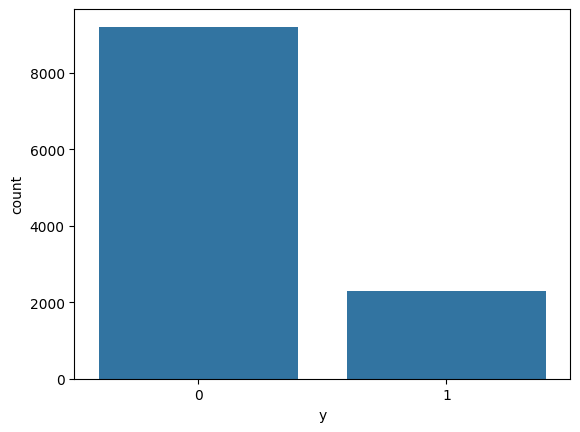

The number of trials for the non-seizure class is: 9200
The number of trials for the seizure class is: 2300


In [4]:
cols = ESR.columns
tgt = ESR.y
tgt[tgt>1] = 0
sn.countplot(x=tgt)
plt.show()

non_seizure, seizure = tgt.value_counts()
print('The number of trials for the non-seizure class is:', non_seizure)
print('The number of trials for the seizure class is:', seizure)

In [5]:
ESR.isnull().sum()

,0
Unnamed,0
X1,0
X2,0
X3,0
X4,0
...,...
X175,0
X176,0
X177,0
X178,0


In [42]:
print(ESR.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 180 entries, Unnamed to y
dtypes: int64(179), object(1)
memory usage: 15.8+ MB
None


In [7]:
ESR.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
count,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.00000,11500.00000,11500.000000,...,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000
mean,-11.581391,-10.911565,-10.187130,-9.143043,-8.009739,-7.003478,-6.502087,-6.68713,-6.55800,-6.168435,...,-10.145739,-11.630348,-12.943478,-13.668870,-13.363304,-13.045043,-12.705130,-12.426000,-12.195652,0.200000
std,165.626284,166.059609,163.524317,161.269041,160.998007,161.328725,161.467837,162.11912,162.03336,160.436352,...,164.652883,166.149790,168.554058,168.556486,167.257290,164.241019,162.895832,162.886311,164.852015,0.400017
min,-1839.000000,-1838.000000,-1835.000000,-1845.000000,-1791.000000,-1757.000000,-1832.000000,-1778.00000,-1840.00000,-1867.000000,...,-1867.000000,-1865.000000,-1642.000000,-1723.000000,-1866.000000,-1863.000000,-1781.000000,-1727.000000,-1829.000000,0.000000
25%,-54.000000,-55.000000,-54.000000,-54.000000,-54.000000,-54.000000,-54.000000,-55.00000,-55.00000,-54.000000,...,-55.000000,-56.000000,-56.000000,-56.000000,-55.000000,-56.000000,-55.000000,-55.000000,-55.000000,0.000000
50%,-8.000000,-8.000000,-7.000000,-8.000000,-8.000000,-8.000000,-8.000000,-8.00000,-7.00000,-7.000000,...,-9.000000,-10.000000,-10.000000,-10.000000,-10.000000,-9.000000,-9.000000,-9.000000,-9.000000,0.000000
75%,34.000000,35.000000,36.000000,36.000000,35.000000,36.000000,35.000000,36.00000,36.00000,35.250000,...,34.000000,34.000000,33.000000,33.000000,34.000000,34.000000,34.000000,34.000000,34.000000,0.000000
max,1726.000000,1713.000000,1697.000000,1612.000000,1518.000000,1816.000000,2047.000000,2047.00000,2047.00000,2047.000000,...,1777.000000,1472.000000,1319.000000,1436.000000,1733.000000,1958.000000,2047.000000,2047.000000,1915.000000,1.000000


In [8]:
X = ESR.iloc[:,1:179].values
X.shape

(11500, 178)

Text(0.5, 0, 'Samples')

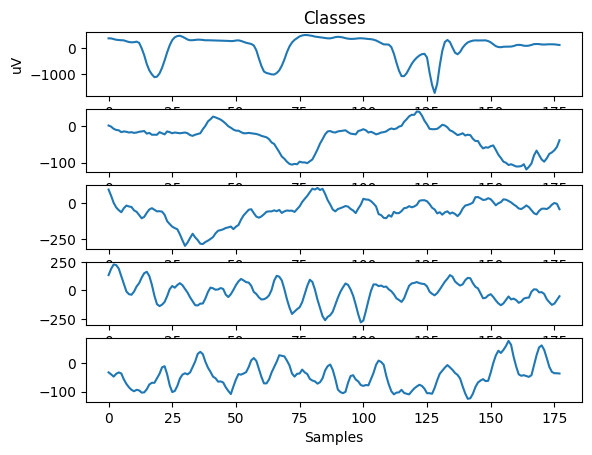

In [9]:
plt.subplot(511)
plt.plot(X[1,:])

plt.title('Classes')
plt.ylabel('uV')

plt.subplot(512)
plt.plot(X[7,:])

plt.subplot(513)
plt.plot(X[12,:])

plt.subplot(514)
plt.plot(X[0,:])

plt.subplot(515)
plt.plot(X[2,:])
plt.xlabel('Samples')

In [10]:
y = ESR.iloc[:,179].values
y

array([0, 1, 0, ..., 0, 0, 0])

In [11]:
y[y>1]=0
y

array([0, 1, 0, ..., 0, 0, 0])

In [12]:
# we taking 20% for testing and 80% for testing  from our date
from sklearn.model_selection import train_test_split, cross_val_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,random_state=42)

In [13]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [14]:
print(X_test)

[[ 0.03661239 -0.01694434  0.03472444 ...  0.00960827  0.01019937
  -0.01950449]
 [-0.17021338 -0.13282799 -0.07044408 ... -0.5018798  -0.21001131
   0.07849396]
 [ 0.76658573  0.70885327  0.30073891 ... -0.02083745 -0.05097026
   0.01112003]
 ...
 [-0.3405405  -0.42558669 -0.54060919 ...  0.56980949  0.59742785
   0.59911071]
 [ 1.70946796  1.73960785  1.38335595 ... -0.97074387 -1.17037456
  -1.21386056]
 [ 0.28601995  0.09893931 -0.18798535 ...  0.42975919  0.43226984
   0.32961498]]


In [15]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train, y_train)

LogisticRegression()

In [16]:
y_pred_log_reg = clf.predict(X_test)
acc_log_reg = round(clf.score(X_train, y_train) * 100, 2)
print (str(acc_log_reg) + ' %')

82.83 %


In [17]:
from sklearn.svm import SVC
clf = SVC()
clf.fit(X_train, y_train)

SVC()

In [18]:
y_pred_svc = clf.predict(X_test)
acc_svc = round(clf.score(X_train, y_train) * 100, 2)
print (str(acc_svc) + '%')

98.16%


In [19]:
from sklearn.svm import SVC, LinearSVC
clf = LinearSVC()
clf.fit(X_train, y_train)

LinearSVC()

In [20]:
y_pred_linear_svc = clf.predict(X_test)
acc_linear_svc = round(clf.score(X_train, y_train) * 100, 2)
print (str(acc_linear_svc) + '%')

82.41%


In [21]:
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier()
clf.fit(X_train, y_train)

KNeighborsClassifier()

In [22]:
y_pred_knn = clf.predict(X_test)
acc_knn = round(clf.score(X_train, y_train) * 100, 2)
print (str(acc_knn)+'%')

94.05%


In [23]:
from sklearn.naive_bayes import GaussianNB
clf = GaussianNB()
clf.fit(X_train, y_train)

GaussianNB()

In [24]:
y_pred_gnb = clf.predict(X_test)
acc_gnb = round(clf.score(X_train, y_train) * 100, 2)
print (str(acc_gnb) + '%')

95.6%


In [25]:
!pip install tensorflow

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [27]:
classifier = Sequential()

In [28]:
# input + Hidden layer

classifier.add(Dense(units=80, kernel_initializer='uniform', activation='relu', input_dim=178))

In [29]:
# hidden layer
classifier.add(Dense(units=80, kernel_initializer='uniform', activation='relu'))

In [30]:
#  output
classifier.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

In [31]:
# compile
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# train
classifier.fit(X_train, y_train, batch_size=10, epochs=100)

Epoch 1/100
920/920 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9433 - loss: 0.2051
Epoch 2/100
920/920 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9686 - loss: 0.0970
Epoch 3/100
920/920 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9735 - loss: 0.0791
Epoch 4/100
920/920 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9758 - loss: 0.0703
Epoch 5/100
920/920 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9798 - loss: 0.0613
Epoch 6/100
920/920 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9815 - loss: 0.0543
Epoch 7/100
920/920 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9830 - loss: 0.0455
Epoch 8/100
920/920 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9841 - loss: 0.0440
Epoch 9/100
920/920 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9839 - loss: 0.0393
Epoch 10/100
920/920 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9872 - loss: 0.0344
Epoch 11/100
920/920 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9876 - loss: 0.0334
Epoch 12/100
920/920 ━━━━━━━━━━━━━━━━━━━━

In [32]:
# Predicting the Test set results
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)
acc_ANN = round(clf.score(X_train, y_train) * 100, 2)
print (str(acc_ANN) + '%')

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
95.6%


In [33]:
from sklearn.decomposition import PCA
pca = PCA()

In [34]:
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
acc_PCA = round(pca.score(X_train, y_train) )
print (str(acc_PCA) + '%')

91%


In [35]:
models = pd.DataFrame({
    'Model': ['Logistic Regression',
              'Support Vector Machines',
              'ANN',
              'KNN',
              'Naive Bayes',
              'Principal Component Analysis'],
    'Score': [acc_log_reg, acc_svc,acc_ANN ,
              acc_knn, acc_gnb,acc_PCA ]
    })
models.sort_values(by='Score', ascending=False)

,Model,Score
1,Support Vector Machines,98.16
2,ANN,95.60
4,Naive Bayes,95.60
3,KNN,94.05
5,Principal Component Analysis,91.00
0,Logistic Regression,82.83


In [36]:
clf = GaussianNB()  # <- this is what gets saved

In [37]:
import pickle

#  ---------------------train your BEST model first svc or Logistic Regression
from sklearn.svm import SVC
best_model = SVC()
best_model.fit(X_train, y_train)

# ---------------------- save best model and scaler
pickle.dump(best_model, open('epilepsy_model.pkl', 'wb'))
pickle.dump(sc, open('scaler.pkl', 'wb'))

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


In [38]:
import os
print(os.path.exists('epilepsy_model.pkl'))  #  print True
print(os.path.exists('scaler.pkl'))           #  print True

True
True


In [39]:
# ------------- Feature Selection: Select Top 10 Features
from sklearn.feature_selection import SelectKBest, f_classif

# find top 10 most important features using ANOVA F-test
selector = SelectKBest(f_classif, k=10)
selector.fit(X_train, y_train)
top_indices = selector.get_support(indices=True)

print("Top 10 Feature Indices (0-based):", top_indices.tolist())
print("Feature Names:", ["X"+str(i+1) for i in top_indices])

# ----------reduce train/test to top 10 features
X_train_top = X_train[:, top_indices]
X_test_top  = X_test[:, top_indices]

Top 10 Feature Indices (0-based): [8, 9, 10, 11, 25, 26, 42, 43, 93, 94]
Feature Names: ['X9', 'X10', 'X11', 'X12', 'X26', 'X27', 'X43', 'X44', 'X94', 'X95']


In [40]:
# ----------- Train Best Model svc on top 10 features
from sklearn.svm import SVC
import pickle

best_model = SVC()
best_model.fit(X_train_top, y_train)

train_acc = round(best_model.score(X_train_top, y_train) * 100, 2)
test_acc  = round(best_model.score(X_test_top,  y_test)  * 100, 2)
print(f"Train Accuracy (10 features): {train_acc}%")
print(f"Test  Accuracy (10 features): {test_acc}%")

Train Accuracy (10 features): 95.1%
Test  Accuracy (10 features): 95.13%


In [41]:
# ------------- saving our model, Scaler, and Selected feature Indices
pickle.dump(best_model,        open("epilepsy_model.pkl", "wb"))
pickle.dump(sc,                open("scaler.pkl",         "wb"))
pickle.dump(top_indices.tolist(), open("top_indices.pkl",  "wb"))

print("Saved: epilepsy_model.pkl, scaler.pkl, top_indices.pkl")
print("you now only 10 EEG values to get a prediction ")

Saved: epilepsy_model.pkl, scaler.pkl, top_indices.pkl
Users now only need to enter 10 EEG values to get a prediction!
